# AdaBoost (1/2) — AdaBoost Step by Step, by Hand

**Idea:** train weak models one after another. After each model, make the rows it got wrong *heavier*, so the next model is forced to focus on them. At the end all models vote, and better models get a louder vote.

**In this notebook**
1. A tiny 10-row dataset (so we can see every number)
2. Labels as ±1 and equal starting weights
3. Round 1: train a decision stump, compute its error and its "say" (alpha)
4. Update the row weights (wrong rows get heavier)
5. Make a new dataset by weighted sampling ("upsampling")
6. Rounds 2 and 3 with one reusable function
7. Final prediction = sign of the weighted vote
8. Compare with scikit-learn's `AdaBoostClassifier`

> 📖 Theory: [`theory.md`](theory.md) §3–§5 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import AdaBoostClassifier

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.precision', 4)

## 1. The toy dataset

10 rows, two features (`X1`, `X2`) and a class `label` (1 = blue, 0 = red). Small enough to follow every number by hand.

In [2]:
df = pd.DataFrame({
    'X1':    [1, 2, 3, 4, 5, 6, 6, 7, 9, 9],
    'X2':    [5, 3, 6, 8, 1, 9, 5, 8, 9, 2],
    'label': [1, 1, 0, 1, 0, 1, 0, 1, 0, 0],
})
X = df[['X1', 'X2']].values
y = df['label'].values
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

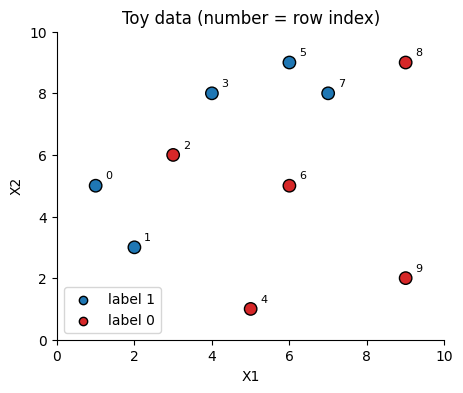

In [3]:
def plot_points(ax, X, y, title=''):
    colors = np.where(y == 1, 'tab:blue', 'tab:red')
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=80, edgecolor='k', zorder=3)
    for i, (a, b) in enumerate(X):
        ax.annotate(str(i), (a, b), textcoords='offset points', xytext=(7, 5), fontsize=8)
    ax.set_xlabel('X1'); ax.set_ylabel('X2'); ax.set_title(title)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)

def plot_boundary(ax, predict_fn, alpha=0.25):
    xx, yy = np.meshgrid(np.linspace(0, 10, 300), np.linspace(0, 10, 300))
    zz = predict_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-1.5, 0.5, 1.5], colors=['tab:red', 'tab:blue'], alpha=alpha)

fig, ax = plt.subplots(figsize=(5, 4))
plot_points(ax, X, y, title='Toy data (number = row index)')
ax.scatter([], [], c='tab:blue', edgecolor='k', label='label 1')
ax.scatter([], [], c='tab:red', edgecolor='k', label='label 0')
ax.legend(loc='lower left'); plt.show()

No single vertical or horizontal line can separate blue from red. A **decision stump** (a tree with only one split) will make mistakes. That is exactly the point: AdaBoost combines several weak stumps into a stronger model.

## 2. Labels as ±1 and equal starting weights

AdaBoost's final vote is `sign(α₁·h₁ + α₂·h₂ + α₃·h₃)`. For the sign to work, a "no" vote must count as **−1**, not 0. So we keep `label` (0/1) for training the sklearn trees and add `y_pm` (±1) for the vote.

Every row starts with the same weight `1/n = 1/10 = 0.1`.

> ✍️ **Core code: learn this.** Convert labels to ±1 and start with equal weights.

In [4]:
n = len(df)
df['y_pm'] = np.where(df['label'] == 1, 1, -1)   # 0 -> -1, 1 -> +1
df['weight'] = 1 / n                              # every row starts with weight 0.1
df

,X1,X2,label,y_pm,weight
0,1,5,1,1,0.1
1,2,3,1,1,0.1
2,3,6,0,-1,0.1
3,4,8,1,1,0.1
4,5,1,0,-1,0.1
5,6,9,1,1,0.1
6,6,5,0,-1,0.1
7,7,8,1,1,0.1
8,9,9,0,-1,0.1
9,9,2,0,-1,0.1


## 3. Round 1: train a stump, find its error and its alpha

In round 1 all weights are equal, so we simply train on the original data. (`random_state=0` makes the choice between equally good splits reproducible.)

> ✍️ **Core code: learn this.** Train a decision stump (`max_depth=1`).

In [5]:
stump1 = DecisionTreeClassifier(max_depth=1, random_state=0)
stump1.fit(X, y)
print(export_text(stump1, feature_names=['X1', 'X2']))

|--- X2 <= 2.50
|   |--- class: 0
|--- X2 >  2.50
|   |--- class: 1



> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

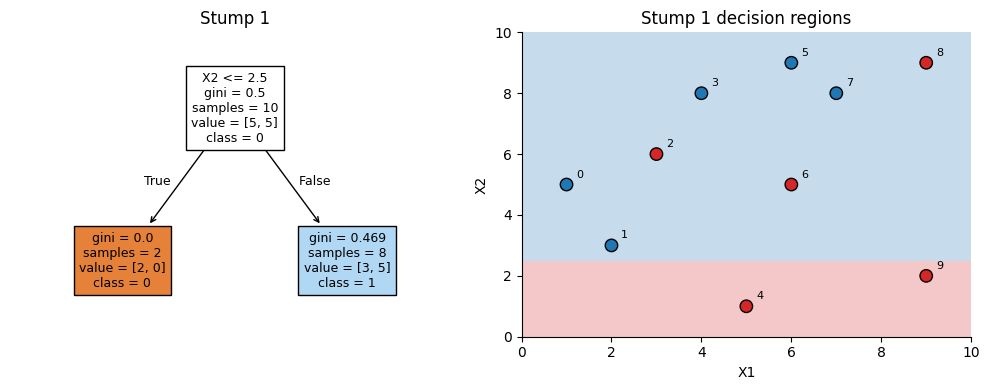

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_tree(stump1, feature_names=['X1', 'X2'], class_names=['0', '1'], filled=True, fontsize=9, ax=axes[0])
axes[0].set_title('Stump 1')
plot_boundary(axes[1], stump1.predict)
plot_points(axes[1], X, y, title='Stump 1 decision regions')
plt.tight_layout(); plt.show()

The stump splits on `X2 <= 2.5`: the bottom strip → class 0 (red), everything else → class 1 (blue).

**Error of a model in AdaBoost = the sum of the weights of the rows it gets wrong** (not simply the count of mistakes).

**Model weight (its "say" in the final vote):**

$$\alpha = \frac{1}{2}\ln\left(\frac{1-\text{error}}{\text{error}}\right)$$

> ✍️ **Core code: learn this.** Compute the weighted error from the actual mistakes, then alpha. Never type these numbers by hand.

In [7]:
def model_weight(error):
    return 0.5 * np.log((1 - error) / error)

df['pred1'] = stump1.predict(X)
df['wrong1'] = df['pred1'] != df['label']

error1 = df.loc[df['wrong1'], 'weight'].sum()
alpha1 = model_weight(error1)
print('Wrong rows:', list(df.index[df['wrong1']]))
print(f'error1 = {error1:.4f}')
print(f'alpha1 = {alpha1:.4f}')

Wrong rows: [2, 6, 8]
error1 = 0.3000
alpha1 = 0.4236


Stump 1 misclassifies rows 2, 6 and 8 → error = 3 × 0.1 = 0.3 → α₁ = ½·ln(0.7/0.3) ≈ 0.4236.

How does alpha react to the error?

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

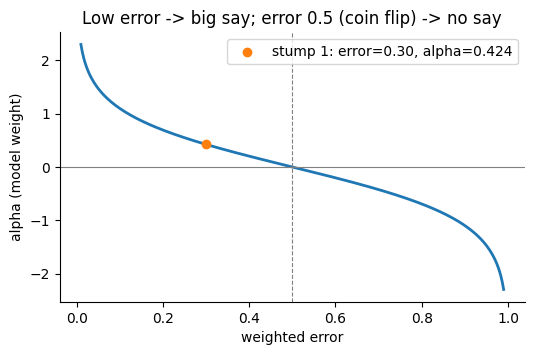

In [8]:
e = np.linspace(0.01, 0.99, 300)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(e, model_weight(e), lw=2)
ax.axhline(0, color='grey', lw=0.8); ax.axvline(0.5, color='grey', ls='--', lw=0.8)
ax.scatter([error1], [alpha1], color='tab:orange', zorder=3, label=f'stump 1: error={error1:.2f}, alpha={alpha1:.3f}')
ax.set_xlabel('weighted error'); ax.set_ylabel('alpha (model weight)')
ax.set_title('Low error -> big say; error 0.5 (coin flip) -> no say')
ax.legend(); plt.show()

- error near 0 → very large alpha (a trusted model)
- error = 0.5 → alpha = 0 (a coin flip gets no say)
- error > 0.5 → negative alpha (its vote is flipped)

## 4. Update the row weights

- correct row: `w × e^(−α)` (gets lighter)
- wrong row: `w × e^(+α)` (gets heavier)

Then divide by the total so the weights sum to 1 again (normalise).

> ✍️ **Core code: learn this.** Update and normalise the weights. This is the heart of AdaBoost.

In [9]:
def update_weights(weights, wrong, alpha):
    new_w = weights * np.exp(np.where(wrong, alpha, -alpha))
    return new_w / new_w.sum()     # normalise so the weights sum to 1

df['w_unnormalised'] = df['weight'] * np.exp(np.where(df['wrong1'], alpha1, -alpha1))
df['weight2'] = update_weights(df['weight'].values, df['wrong1'].values, alpha1)
print('sum before normalising:', round(df['w_unnormalised'].sum(), 4))
df[['X1', 'X2', 'label', 'pred1', 'wrong1', 'weight', 'w_unnormalised', 'weight2']]

sum before normalising: 0.9165


,X1,X2,label,pred1,wrong1,weight,w_unnormalised,weight2
0,1,5,1,1,False,0.1,0.0655,0.0714
1,2,3,1,1,False,0.1,0.0655,0.0714
2,3,6,0,1,True,0.1,0.1528,0.1667
3,4,8,1,1,False,0.1,0.0655,0.0714
4,5,1,0,0,False,0.1,0.0655,0.0714
5,6,9,1,1,False,0.1,0.0655,0.0714
6,6,5,0,1,True,0.1,0.1528,0.1667
7,7,8,1,1,False,0.1,0.0655,0.0714
8,9,9,0,1,True,0.1,0.1528,0.1667
9,9,2,0,0,False,0.1,0.0655,0.0714


The 3 wrong rows went from 0.1 to **0.1667**; the 7 correct rows dropped to **0.0714**. After normalising, the wrong rows together hold exactly **half** of the total weight (3 × 0.1667 = 0.5). This always happens in AdaBoost: on the new weights, the previous model is no better than a coin flip, so the next model *must* learn something new.

## 5. Make a new dataset by weighted sampling ("upsampling")

The CampusX lecture trains the next stump on a **new dataset sampled from the old one**, where heavy rows are more likely to be picked:

1. Turn the weights into cumulative ranges: row 0 owns [0, 0.0714), row 1 owns [0.0714, 0.1429), …
2. Draw a random number between 0 and 1; the row whose range contains it is picked.
3. Repeat n times (with replacement).

Heavy rows own wider ranges, so they get picked more often. We use a **fixed seed** so the result is the same every time you run the notebook.

> ✍️ **Core code: learn this.** Weighted resampling with cumulative ranges.

In [10]:
rng = np.random.default_rng(2)   # fixed seed -> same samples every run

def weighted_resample(weights, rng):
    upper = np.cumsum(weights)                     # right end of each row's range
    r = rng.random(len(weights))                   # n random numbers in [0, 1)
    idx = np.searchsorted(upper, r, side='right')  # which range each number falls into
    return idx, r

df['range_low'] = df['weight2'].cumsum() - df['weight2']
df['range_high'] = df['weight2'].cumsum()
idx2, r2 = weighted_resample(df['weight2'].values, rng)

display(df[['X1', 'X2', 'label', 'weight2', 'range_low', 'range_high']])
print('random numbers:', np.round(r2, 3))
print('picked rows   :', idx2)

,X1,X2,label,weight2,range_low,range_high
0,1,5,1,0.0714,0.0000,0.0714
1,2,3,1,0.0714,0.0714,0.1429
2,3,6,0,0.1667,0.1429,0.3095
3,4,8,1,0.0714,0.3095,0.3810
4,5,1,0,0.0714,0.3810,0.4524
5,6,9,1,0.0714,0.4524,0.5238
6,6,5,0,0.1667,0.5238,0.6905
7,7,8,1,0.0714,0.6905,0.7619
8,9,9,0,0.1667,0.7619,0.9286
9,9,2,0,0.0714,0.9286,1.0000


random numbers: [0.262 0.298 0.814 0.092 0.6   0.729 0.188 0.055 0.275 0.657]
picked rows   : [2 2 8 1 6 7 2 0 2 6]


In [11]:
counts = pd.Series(idx2).value_counts().reindex(range(n), fill_value=0)
pd.DataFrame({'weight2': df['weight2'].round(4), 'wrong_in_round1': df['wrong1'], 'times_picked': counts})

,weight2,wrong_in_round1,times_picked
0,0.0714,False,1
1,0.0714,False,1
2,0.1667,True,4
3,0.0714,False,0
4,0.0714,False,0
5,0.0714,False,0
6,0.1667,True,2
7,0.0714,False,1
8,0.1667,True,1
9,0.0714,False,0


Rows 2, 6 and 8 (the mistakes of stump 1) fill **7 of the 10 places** in the new dataset (row 2 alone is picked 4 times), while rows 3, 4, 5 and 9 are not picked at all. With only 10 draws the counts are noisy, and **resampling is random**: a different seed gives a different sample and possibly different later stumps. That is why we fixed the seed.

## 6. Rounds 2 and 3 with one function

Every round does the same 5 things: train a stump → find wrong rows → error → alpha → new weights. One detail that is easy to get wrong (the original lecture code mixed this up):

> The new stump is **trained** on the resampled data, but its **error is measured on the original 10 rows using their current weights**, and it is the **weights of the original 10 rows** that get updated. The resampled data is only a training aid.

> ✍️ **Core code: learn this.** One full AdaBoost round.

In [12]:
def adaboost_round(X_train, y_train, weights):
    stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X_train, y_train)
    wrong = stump.predict(X) != y                 # judged on the ORIGINAL 10 rows
    error = weights[wrong].sum()
    alpha = model_weight(error)
    new_weights = update_weights(weights, wrong, alpha)
    return stump, wrong, error, alpha, new_weights

# Round 2: train on the resampled data from section 5
stump2, wrong2, error2, alpha2, weight3 = adaboost_round(X[idx2], y[idx2], df['weight2'].values)
print(export_text(stump2, feature_names=['X1', 'X2']))
print('wrong rows:', np.where(wrong2)[0].tolist(), f'| error2 = {error2:.4f} | alpha2 = {alpha2:.4f}')

|--- X1 <= 2.50
|   |--- class: 1
|--- X1 >  2.50
|   |--- class: 0

wrong rows: [3, 5, 7] | error2 = 0.2143 | alpha2 = 0.6496


In [13]:
# Round 3: resample with the NEW weights, then train stump 3 on that new sample
idx3, r3 = weighted_resample(weight3, rng)
print('picked rows for round 3:', idx3)
stump3, wrong3, error3, alpha3, weight4 = adaboost_round(X[idx3], y[idx3], weight3)
print(export_text(stump3, feature_names=['X1', 'X2']))
print('wrong rows:', np.where(wrong3)[0].tolist(), f'| error3 = {error3:.4f} | alpha3 = {alpha3:.4f}')

picked rows for round 3: [5 2 5 6 5 6 9 7 4 2]
|--- X2 <= 7.00
|   |--- class: 0
|--- X2 >  7.00
|   |--- class: 1

wrong rows: [0, 1, 8] | error3 = 0.1970 | alpha3 = 0.7027


### The weight table across rounds

`w_roundk` = the weight a row had **when stump k was judged**; `wrong_k` = did stump k get it wrong? Watch rows grow after a mistake and shrink after a correct answer.

In [14]:
weights_table = pd.DataFrame({
    'X1': df['X1'], 'X2': df['X2'], 'label': df['label'],
    'w_round1': df['weight'], 'wrong_1': df['wrong1'],
    'w_round2': df['weight2'], 'wrong_2': wrong2,
    'w_round3': weight3, 'wrong_3': wrong3,
    'w_after3': weight4,
})
weights_table.round(4)

,X1,X2,label,w_round1,wrong_1,w_round2,wrong_2,w_round3,wrong_3,w_after3
0,1,5,1,0.1,False,0.0714,False,0.0455,True,0.1154
1,2,3,1,0.1,False,0.0714,False,0.0455,True,0.1154
2,3,6,0,0.1,True,0.1667,False,0.1061,False,0.0660
3,4,8,1,0.1,False,0.0714,True,0.1667,False,0.1038
4,5,1,0,0.1,False,0.0714,False,0.0455,False,0.0283
5,6,9,1,0.1,False,0.0714,True,0.1667,False,0.1038
6,6,5,0,0.1,True,0.1667,False,0.1061,False,0.0660
7,7,8,1,0.1,False,0.0714,True,0.1667,False,0.1038
8,9,9,0,0.1,True,0.1667,False,0.1061,True,0.2692
9,9,2,0,0.1,False,0.0714,False,0.0455,False,0.0283


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

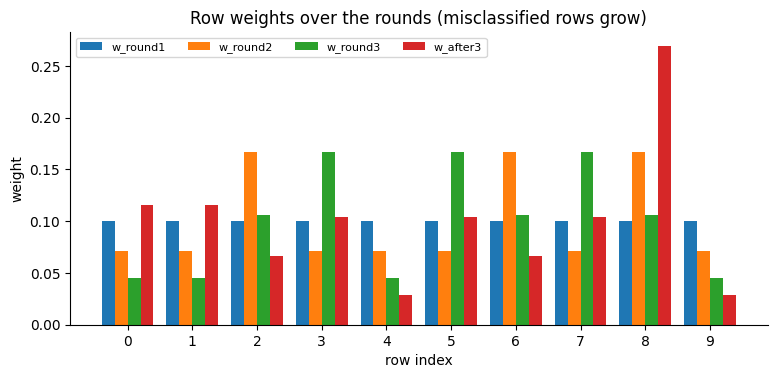

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.8))
cols = ['w_round1', 'w_round2', 'w_round3', 'w_after3']
width = 0.2
for k, c in enumerate(cols):
    ax.bar(np.arange(n) + (k - 1.5) * width, weights_table[c], width, label=c)
ax.set_xticks(range(n)); ax.set_xlabel('row index'); ax.set_ylabel('weight')
ax.set_title('Row weights over the rounds (misclassified rows grow)')
ax.legend(ncol=4, fontsize=8); plt.show()

In [16]:
def rule(stump):
    return export_text(stump, feature_names=['X1', 'X2']).split('\n')[0].replace('|--- ', '')

rounds = pd.DataFrame({
    'stump': [1, 2, 3],
    'rule (left side)': [rule(s) for s in (stump1, stump2, stump3)],
    'wrong rows': [list(np.where(w)[0]) for w in (df['wrong1'].values, wrong2, wrong3)],
    'error': [error1, error2, error3],
    'alpha': [alpha1, alpha2, alpha3],
})
rounds.round(4)

,stump,rule (left side),wrong rows,error,alpha
0,1,X2 <= 2.50,"[2, 6, 8]",0.3000,0.4236
1,2,X1 <= 2.50,"[3, 5, 7]",0.2143,0.6496
2,3,X2 <= 7.00,"[0, 1, 8]",0.1970,0.7027


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

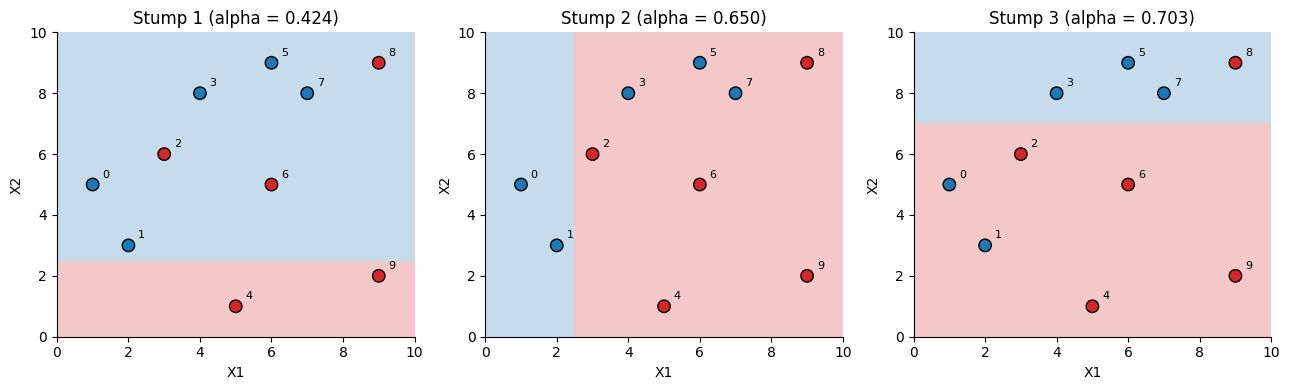

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, s, a, name in zip(axes, (stump1, stump2, stump3), (alpha1, alpha2, alpha3), ('Stump 1', 'Stump 2', 'Stump 3')):
    plot_boundary(ax, s.predict)
    plot_points(ax, X, y, title=f'{name} (alpha = {a:.3f})')
plt.tight_layout(); plt.show()

Read the table and the plots together:

- **Stump 2** (`X1 <= 2.5`) gets stump 1's mistakes (rows 2, 6, 8) right, but misses rows 3, 5, 7.
- **Stump 3** (`X2 <= 7.0`) gets rows 3, 5, 7 right, but misses rows 0, 1, 8.
- Stump 3 also misses 3 rows, yet its error is only 0.197: rows 0 and 1 were light at that point (0.0455 each). **The error counts weight, not rows.**
- Errors went 0.300 → 0.214 → 0.197, so the alphas grew 0.424 → 0.650 → 0.703.

## 7. Prediction: the weighted vote

For a new point each stump votes +1 or −1. Multiply each vote by that stump's alpha, add them up, and take the **sign**:

$$H(x) = \text{sign}\big(\alpha_1 h_1(x) + \alpha_2 h_2(x) + \alpha_3 h_3(x)\big)$$

> ✍️ **Core code: learn this.** Weighted vote with ±1 votes and the sign.

In [18]:
stumps = [stump1, stump2, stump3]
alphas = np.array([alpha1, alpha2, alpha3])

def to_pm(pred01):
    return np.where(pred01 == 1, 1, -1)

def adaboost_score(points):
    votes = np.column_stack([to_pm(s.predict(points)) for s in stumps])  # shape (m, 3), values ±1
    return votes @ alphas                                                 # weighted sum

def adaboost_predict(points):
    return np.where(adaboost_score(points) > 0, 1, 0)   # sign -> back to 0/1 labels

for q in ([1, 5], [9, 9]):
    q = np.array([q])
    votes = [int(to_pm(s.predict(q))[0]) for s in stumps]
    score = adaboost_score(q)[0]
    print(f'query {q[0]}: votes = {votes}, score = {score:+.4f}, sign = {int(np.sign(score)):+d}')

query [1 5]: votes = [1, 1, -1], score = +0.3706, sign = +1
query [9 9]: votes = [1, -1, 1], score = +0.4767, sign = +1


Let's check both queries by hand:

| query | true label | votes (h₁, h₂, h₃) | score | prediction |
|---|---|---|---|---|
| (1, 5) = row 0 | 1 | +1, +1, −1 | 0.4236 + 0.6496 − 0.7027 = **+0.3706** | +1 → class 1 ✅ |
| (9, 9) = row 8 | 0 | +1, −1, +1 | 0.4236 − 0.6496 + 0.7027 = **+0.4767** | +1 → class 1 ❌ |

**Honest note:** the original lecture notebook got −1 (correct) for (9, 9). That only happened because of hand-typed alphas and a stump 3 trained on the wrong data. With every number computed properly, 3 stumps are **not enough** for this point. Notice that row 8 is now by far the heaviest row (0.269 in `w_after3`), so a 4th stump would focus on it. That is boosting at work.

In [19]:
df['score'] = adaboost_score(X)
df['final_pred'] = adaboost_predict(X)
print('Training accuracy of our 3-stump AdaBoost:', (df['final_pred'] == df['label']).mean())
df[['X1', 'X2', 'label', 'score', 'final_pred']]

Training accuracy of our 3-stump AdaBoost: 0.9


,X1,X2,label,score,final_pred
0,1,5,1,0.3706,1
1,2,3,1,0.3706,1
2,3,6,0,-0.9287,0
3,4,8,1,0.4767,1
4,5,1,0,-1.7760,0
5,6,9,1,0.4767,1
6,6,5,0,-0.9287,0
7,7,8,1,0.4767,1
8,9,9,0,0.4767,1
9,9,2,0,-1.7760,0


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

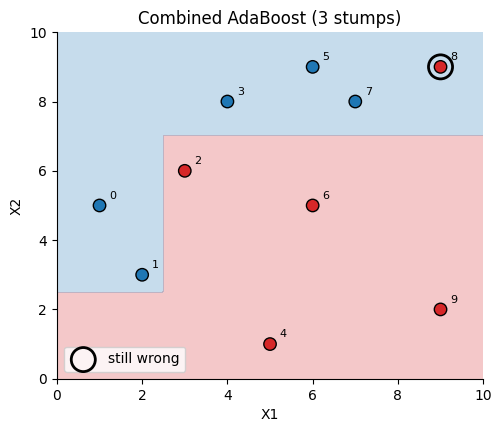

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_boundary(ax, adaboost_predict)
plot_points(ax, X, y, title='Combined AdaBoost (3 stumps)')
wrong_final = (df['final_pred'] != df['label']).values
ax.scatter(X[wrong_final, 0], X[wrong_final, 1], s=300, facecolors='none', edgecolors='k', lw=2, label='still wrong')
ax.legend(loc='lower left'); plt.show()

Our 3-stump model gets **9 of 10** training rows right; only row 8 is still wrong. Look at the shape of the boundary: a **staircase** that no single stump could draw. Weak, one-line models add up to a more flexible model. This is how boosting reduces **bias**.

## 8. Compare with scikit-learn's `AdaBoostClassifier`

Now the same idea in one line of sklearn: 3 stumps.

> ✍️ **Core code: learn this.** The sklearn version (modern API: `estimator=`, no `algorithm` argument).

In [21]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                         n_estimators=3, random_state=0)
ada.fit(X, y)

sk = pd.DataFrame({
    'rule (left side)': [rule(s) for s in ada.estimators_],
    'error (estimator_errors_)': ada.estimator_errors_,
    'sklearn weight (estimator_weights_)': ada.estimator_weights_,
})
display(sk.round(4))
print('sklearn training accuracy:', ada.score(X, y))

,rule (left side),error (estimator_errors_),sklearn weight (estimator_weights_)
0,X1 <= 2.50,0.3000,0.8473
1,X2 <= 7.00,0.2143,1.2993
2,X1 <= 8.00,0.1364,1.8458


sklearn training accuracy: 1.0


sklearn reaches **10/10** training accuracy with 3 stumps, and its stumps are different from ours (`X1 <= 2.5`, `X2 <= 7.0`, `X1 <= 8.0`). Two honest reasons:

1. **A tie in round 1.** `X1 <= 2.5` and `X2 <= 2.5` are equally good first splits: each cuts off a pure group of 2 rows, both have error 0.3. Our tree picked one, sklearn's tree picked the other.
2. **sklearn does not resample.** It passes the weights directly to the tree with `sample_weight` (reweighting). Our version (and the lecture) draws a random new dataset, so it depends on the seed.

To prove our formulas are the same as sklearn's, let's redo the rounds by hand, but with **reweighting** instead of resampling.

> ✍️ **Core code: learn this.** Reweighting instead of resampling: pass the weights straight to the stump with `sample_weight`.

In [22]:
# Give each stump the same random_state sklearn used, so ties between equally good splits break the same way
sk_seeds = [s.random_state for s in ada.estimators_]

w = np.full(n, 1 / n)
rows = []
for m in range(3):
    stump = DecisionTreeClassifier(max_depth=1, random_state=sk_seeds[m]).fit(X, y, sample_weight=w)
    wrong = stump.predict(X) != y
    err = w[wrong].sum()
    a = model_weight(err)
    rows.append({'rule (left side)': rule(stump), 'wrong rows': list(np.where(wrong)[0]),
                 'error': err, 'our alpha': a, '2 x our alpha': 2 * a})
    w = update_weights(w, wrong, a)

pd.DataFrame(rows).round(4)

,rule (left side),wrong rows,error,our alpha,2 x our alpha
0,X1 <= 2.50,"[3, 5, 7]",0.3000,0.4236,0.8473
1,X2 <= 7.00,"[0, 1, 8]",0.2143,0.6496,1.2993
2,X1 <= 8.00,"[2, 4, 6]",0.1364,0.9229,1.8458


**Exact match.** With reweighting, our hand-written loop finds the same stumps and the same errors as sklearn, and sklearn's `estimator_weights_` are exactly **2 × our alpha**.

Why the factor 2? sklearn's SAMME algorithm uses `α = ln((1−err)/err)` (no ½) and multiplies only the *wrong* rows by `e^α`. After normalising, that gives exactly the same row weights as our "× e^(−α) / × e^(+α)" rule. And multiplying every alpha by 2 never changes the **sign** of the vote, so the predictions are identical.

| | Our hand version (sections 3–7) | sklearn `AdaBoostClassifier` |
|---|---|---|
| How the next model "sees" the weights | resample a new dataset (random) | `sample_weight` passed to the tree (no sampling) |
| alpha formula | ½·ln((1−e)/e) | ln((1−e)/e) = 2 × ours (same predictions) |
| Randomness | depends on the resampling seed | only tie-breaking between equal splits (`random_state`) |

## Key takeaways

- AdaBoost trains models **sequentially**; each new stump focuses on the rows the previous stumps got wrong.
- **Error = sum of the weights of the wrong rows**, and **α = ½·ln((1−error)/error)**. Compute both from the data; never type them by hand.
- Wrong rows get `× e^α`, correct rows `× e^(−α)`, then normalise. After normalising, the wrong rows always hold half of the total weight.
- Resampling is one way to make the next model "see" the weights; it is random, so fix a seed. sklearn passes `sample_weight` directly instead.
- Prediction = **sign(Σ αₘ·hₘ(x))** with votes as **±1**, not 0/1.

## 🧠 Quick check

<details><summary>A stump gets 2 out of 10 rows wrong, but those two rows have weight 0.25 each. What is its error?</summary>
0.25 + 0.25 = 0.5. In AdaBoost the error is the sum of the weights of the wrong rows, not 2/10. With error 0.5 its alpha is 0, so it gets no say at all.
</details>

<details><summary>Why must the labels be −1/+1 for the final vote?</summary>
Because the vote is sign(Σ α·h). If "no" were 0, a "no" vote would add nothing instead of pushing the score negative, so the vote would lean towards class 1.
</details>

<details><summary>Is the error of stump 2 measured on the resampled dataset or on the original rows?</summary>
On the original rows, using their current weights. The resampled data is only used to train the stump, and it is the weights of the original rows that get updated.
</details>

<details><summary>sklearn's estimator_weights_ are twice our alphas. Does sklearn predict differently?</summary>
No. Multiplying every alpha by the same positive number never changes the sign of the weighted sum, so the predictions are the same.
</details>

➡️ **Next:** [`02-adaboost-hyperparameters.ipynb`](02-adaboost-hyperparameters.ipynb): AdaBoost on a harder dataset, and how `n_estimators`, `learning_rate` and the base-estimator depth change it.